

# **Submission for:**  Assignment 3   
**by** 
- Michael Berger, 318063864  
- Barack Samuni, 318299625

## **Course**: 65027 - Cloud Technologies and Big Data
## **Program:** Intelligent Systems  
## **Course coordinator:** Dr. Morose Boris



**The purpose of this Lab is to practice SPARK Feature Manipulations**

**Problem definition**:



## 1.  Read data from the file "dataFIFA.scv".


In [111]:
import numpy as np
import pandas as pd
from IPython.display import Markdown
import plotly.express as px
from plotly.subplots import make_subplots

%matplotlib inline

### Data exploration

In [112]:
fifa = pd.read_csv("data/dataFIFA.csv", index_col=0)
# Loaned From only has 6% non-nulls, so we drop it immediately
del fifa["Loaned From"]
original = fifa.copy()
fifa

,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,158023,L. Messi,31,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94,94,FC Barcelona,https://cdn.sofifa.org/teams/2/light/241.png,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,20801,Cristiano Ronaldo,33,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Juventus,https://cdn.sofifa.org/teams/2/light/45.png,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,190871,Neymar Jr,26,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,93,Paris Saint-Germain,https://cdn.sofifa.org/teams/2/light/73.png,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,193080,De Gea,27,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91,93,Manchester United,https://cdn.sofifa.org/teams/2/light/11.png,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,192985,K. De Bruyne,27,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91,92,Manchester City,https://cdn.sofifa.org/teams/2/light/10.png,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18202,238813,J. Lundstram,19,https://cdn.sofifa.org/players/4/19/238813.png,England,https://cdn.sofifa.org/flags/14.png,47,65,Crewe Alexandra,https://cdn.sofifa.org/teams/2/light/121.png,...,45.0,40.0,48.0,47.0,10.0,13.0,7.0,8.0,9.0,€143K
18203,243165,N. Christoffersson,19,https://cdn.sofifa.org/players/4/19/243165.png,Sweden,https://cdn.sofifa.org/flags/46.png,47,63,Trelleborgs FF,https://cdn.sofifa.org/teams/2/light/703.png,...,42.0,22.0,15.0,19.0,10.0,9.0,9.0,5.0,12.0,€113K
18204,241638,B. Worman,16,https://cdn.sofifa.org/players/4/19/241638.png,England,https://cdn.sofifa.org/flags/14.png,47,67,Cambridge United,https://cdn.sofifa.org/teams/2/light/1944.png,...,41.0,32.0,13.0,11.0,6.0,5.0,10.0,6.0,13.0,€165K
18205,246268,D. Walker-Rice,17,https://cdn.sofifa.org/players/4/19/246268.png,England,https://cdn.sofifa.org/flags/14.png,47,66,Tranmere Rovers,https://cdn.sofifa.org/teams/2/light/15048.png,...,46.0,20.0,25.0,27.0,14.0,6.0,14.0,8.0,9.0,€143K


In [113]:
def summary(df: pd.DataFrame, by: int = 4, ascending: bool = False):
    """a neat summary of a dataframe

    Args:
        df (pd.DataFrame): A DataFrame to summarize
        by (int, optional): column number to sort by. Defaults to 4 (unique values).
        ascending (bool, optional): whether to sort ascending. Defaults to False (descending).

    Returns:
        pd.DataFrame: a new DataFrame representing the summary of df
    """

    nonnans = df.shape[0] - df.isna().sum()
    nonnansPrc = nonnans / df.shape[0] * 100  # .apply("{0:.2f}%".format)

    # prevent examples column from being all nans by sampling from subset where all columns are nonna.
    df_nona = df.dropna(axis=0)
    if df_nona.shape[0] < 1:
        sam = df.sample(1, random_state=42).squeeze()
    else:
        sam = df_nona.sample(1, random_state=42).squeeze()

    nanExamples = sam.isna().sum() / sam.shape[0]
    if nanExamples > 0.1:
        print(
            f"Warning! examples for {100 * nanExamples:.0f}% of columns are nans. \
              \nMaybe try dropping columns that have majority nan values..."
        )

    res = pd.DataFrame(
        [
            sam.index,
            df.dtypes.astype(str),
            nonnans,
            nonnansPrc,
            df.nunique(),
            sam.astype(str),
        ]
    ).transpose()
    if res.shape[0] > 20:
        pd.set_option("display.max_rows", res.shape[0])

    print(
        f"The Dataframe has: \n {df.shape[1]} columns overall \n {df.shape[0]} rows overall"
    )
    cols = [
        "column name",
        "data type",
        "non-null values",
        "non-null values %",
        "unique values",
        "example",
    ]
    sym = "↑" if ascending else "↓"
    cols[by] = sym + cols[by] + sym
    res.columns = cols

    fmt = {
        cols[3]: "{0:.2f}%",
    }

    res.sort_values(res.columns[by], ascending=ascending, inplace=True)
    styled = res.style.format(fmt)
    styled.to_excel("summary.xlsx", index=False)
    display(styled)
    return res

In [114]:
summ = summary(fifa, 3, 0)

The Dataframe has: 
 87 columns overall 
 18207 rows overall


,column name,data type,non-null values,↓non-null values %↓,unique values,example
0,ID,int64,18207,100.00%,18207,246165
7,Potential,int64,18207,100.00%,47,73
1,Name,object,18207,100.00%,17194,J. Sinisterra
12,Special,int64,18207,100.00%,1422,1430
10,Value,object,18207,100.00%,217,€400K
9,Club Logo,object,18207,100.00%,679,https://cdn.sofifa.org/teams/2/light/110395.png
11,Wage,object,18207,100.00%,144,€2K
6,Overall,int64,18207,100.00%,48,60
5,Flag,object,18207,100.00%,164,https://cdn.sofifa.org/flags/56.png
4,Nationality,object,18207,100.00%,164,Colombia


There are some columns with strange values, like:  

CDM	38+2  
LB	42+2  
RB	42+2  
LWB	45+2  

These columns refer to football (soccer) player positions and their ratings  
The first number (e.g., 38) represents the player's base rating or score for that position.  
The +2 indicates a potential improvement or bonus to the player's base rating for that position.  

They are distributed like this:


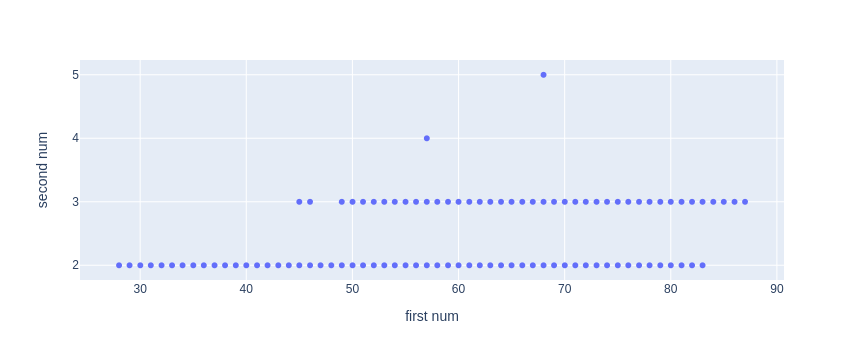

In [115]:
rdm = pd.DataFrame(fifa.RDM.unique(), columns=["val"])
rdm.val.apply(lambda v: str(v).split("+"))
rdm.dropna(inplace=True)
rdm[["first num", "second num"]] = rdm["val"].str.split("+", n=1, expand=True)
rdm["first num"] = rdm["first num"].astype(int)
rdm["second num"] = rdm["second num"].astype(int)
px.scatter(rdm, x="first num", y="second num")


Bottom line, we can disregard second number and take the firs number as int.


<AxesSubplot:>

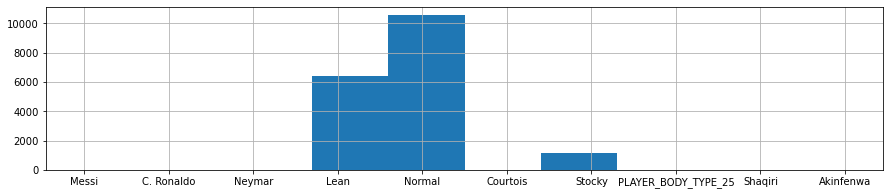

In [116]:
fifa["Body Type"].hist(figsize=[15, 3])

Body Type has some unrelated values. We'll replace them with Normal

In [117]:
fifa["Work Rate"].unique()

array(['Medium/ Medium', 'High/ Low', 'High/ Medium', 'High/ High',
       'Medium/ High', 'Medium/ Low', 'Low/ High', 'Low/ Medium',
       'Low/ Low', nan], dtype=object)

In association football, work rate refers to the extent to which a player contributes to running and chasing in a match while not in possession of the ball.   
The first is for attack and second is for defense.  
We'll spoit this column into 2 categorical columns: attaack, defence

### Data cleaning

The above summary is exported to excel file.   
Then, manually each column is assigned:  
What to do with it:
 - take
 - drop
 - expand

How to treat it: identifier for a function that treats this column

That file then is loaded back to environment to serve as list of instructions.  



In [118]:
summ_rev = pd.read_excel("summary_reviewed.xlsx")
summ_rev

,column name,data type,non-null values,non-null values %,↓unique values↓,example,feature type,todo,how
0,ID,int64,18207,100.000000,18207,246165,index,take,asis
1,Photo,object,18207,100.000000,18207,https://cdn.sofifa.org/players/4/19/246165.png,meta,drop,NaN
2,Name,object,18207,100.000000,17194,J. Sinisterra,meta,drop,NaN
3,Joined,object,16654,91.470314,1736,"Oct 5, 2018",meta,drop,NaN
4,Special,int64,18207,100.000000,1422,1430,continious,take,asis
5,Release Clause,object,16643,91.409897,1244,€850K,meta,drop,NaN
6,Club Logo,object,18207,100.000000,679,https://cdn.sofifa.org/teams/2/light/110395.png,meta,drop,NaN
7,Club,object,17966,98.676333,651,Club Atlético Lanús,categ,drop,NaN
8,Value,object,18207,100.000000,217,€400K,int,take,money
9,Flag,object,18207,100.000000,164,https://cdn.sofifa.org/flags/56.png,meta,drop,NaN


Prepare columns to drop

In [119]:
drop = summ_rev["column name"][summ_rev.todo == "drop"].values
drop

array(['Photo', 'Name', 'Joined', 'Release Clause', 'Club Logo', 'Club',
       'Flag', 'Nationality', 'Jersey Number', 'Contract Valid Until',
       'Position', 'International Reputation', 'Real Face'], dtype=object)

Define utility functions and vars

In [120]:
feetconversions = [30.48, 2.54]


def bodyType(bt):
    ok = ["Lean", "Normal", "Stocky"]
    if bt not in ok:
        bt = "Normal"
    return bt

In [121]:
def WorkRate(r):
    t = r["Work Rate"]
    if pd.isna(t):
        t = [np.nan, np.nan]
    else:
        t = t.split("/ ")
    if len(t) == 1:
        t = t + [np.nan]
    return pd.Series(t, index=["Attack", "Defence"])


# test it:
# fifa.apply( WorkRate, axis =1, result_type='expand')

Prepare mappings for parsers and expanders

In [122]:
parsers = {
    # €850K  -> 850000
    "money": lambda v: (
        eval(str(v).replace("€", "").replace("K", "*1000").replace("M", "*1000000"))
        if pd.notna(v)
        else v
    ),  # quick and dirty, not very secure
    # 56+2   -> 56
    "score": lambda v: int(float(str(v).split("+")[0])) if pd.notna(v) else v,
    # 154lbs -> 154
    "lbs": lambda v: int(str(v).replace("lbs", "")) if pd.notna(v) else v,
    # 5'8    -> 177.8 [cm]
    "feetInch": lambda v: (
        pd.Series(map(int, v.split("'"))).dot(feetconversions) if pd.notna(v) else v
    ),
    # replace anything other than ['Lean', 'Normal', 'Stocky'] with 'Normal'
    "bodyType": lambda v: bodyType(v) if pd.notna(v) else v,
    # verbatim: 258 -> 258
    "asis": lambda v: v,
}

parsers

{'money': <function __main__.<lambda>(v)>,
 'score': <function __main__.<lambda>(v)>,
 'lbs': <function __main__.<lambda>(v)>,
 'feetInch': <function __main__.<lambda>(v)>,
 'bodyType': <function __main__.<lambda>(v)>,
 'asis': <function __main__.<lambda>(v)>}

In [123]:
expanders = {
    # High/ Medium -> 2 columns: High, Medium
    "WorkRate": WorkRate,
}

expanders

{'WorkRate': <function __main__.WorkRate(r)>}

Mapping the columns

In [124]:
# perform dropping of unneeded columns

fifa.drop(drop, axis=1, inplace=True)

In [125]:
# perform parsing columns

for k, v in parsers.items():
    cols = summ_rev["column name"][summ_rev.how == k].values
    fifa[cols] = fifa[cols].applymap(v)

In [126]:
# perform expanding columns

for k, v in expanders.items():
    cols = summ_rev["column name"][summ_rev.how == k].values
    newcols = fifa.apply(v, axis=1, result_type="expand")
    fifa[newcols.columns] = newcols
# drop original column
fifa.drop(cols, axis=1, inplace=True)

In [127]:
summary(fifa, 3);

The Dataframe has: 
 75 columns overall 
 18207 rows overall


,column name,data type,non-null values,↓non-null values %↓,unique values,example
0,ID,int64,18207,100.00%,18207,229862
2,Overall,int64,18207,100.00%,48,70
3,Potential,int64,18207,100.00%,47,81
4,Value,float64,18207,100.00%,217,3000000.0
5,Wage,int64,18207,100.00%,144,5000
6,Special,int64,18207,100.00%,1422,1706
1,Age,int64,18207,100.00%,29,21
49,Acceleration,float64,18159,99.74%,86,65.0
55,Jumping,float64,18159,99.74%,74,46.0
54,ShotPower,float64,18159,99.74%,92,68.0


### Data filling

In [128]:
fifa_filled = fifa.ffill()
summary(fifa_filled);

The Dataframe has: 
 75 columns overall 
 18207 rows overall


,column name,data type,non-null values,non-null values %,↓unique values↓,example
0,ID,int64,18207,100.00%,18207,229692
6,Special,int64,18207,100.00%,1422,1214
4,Value,float64,18207,100.00%,217,1200000.0
5,Wage,int64,18207,100.00%,144,8000
44,Dribbling,float64,18207,100.00%,94,22.0
61,Positioning,float64,18207,100.00%,94,20.0
40,Finishing,float64,18207,100.00%,93,16.0
65,Marking,float64,18207,100.00%,92,22.0
58,LongShots,float64,18207,100.00%,92,14.0
54,ShotPower,float64,18207,100.00%,92,25.0


## 2.  The purpose of this LAB 
Is to find players that belongs to the group of players with top 10 salaries.  
Decide about the type of the feature defined in each column (categorical, numerical, binary).  
Choose 5 more promising feature for clustering to define if 10 players with biggest salary belong to the same cluster   
 

### Feature selection

In [134]:
import plotly.graph_objects as go
from sklearn.feature_selection import RFECV
from sklearn.model_selection import RepeatedKFold
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

In [135]:
X = fifa_filled.drop(["ID", "Wage"], axis=1)
t = fifa_filled["Wage"]

In [136]:
# find best subset of features on this dataset
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns
all_cols = categorical_cols.tolist() + numerical_cols.tolist()

In [137]:
# encode variables
ct_enc_std = ColumnTransformer(
    [
        ("encoding", OrdinalEncoder(), categorical_cols),
        ("standard", StandardScaler(), numerical_cols),
    ]
)
X_encoded = pd.DataFrame(ct_enc_std.fit_transform(X, t), columns=all_cols)
X_encoded

,Preferred Foot,Body Type,Attack,Defence,Age,Overall,Potential,Value,Special,Weak Foot,...,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes
0,0.0,1.0,2.0,2.0,1.258678,4.018287,3.698092,19.319674,2.216573,1.595825,...,1.687329,3.268741,-0.720198,-0.911688,-0.926013,-0.600346,-0.318615,-0.073911,-0.139247,-0.484371
1,1.0,1.0,0.0,1.0,1.686961,4.018287,3.698092,13.331948,2.311958,1.595825,...,2.324430,3.181300,-0.971379,-0.773102,-1.067036,-0.543759,-0.318615,-0.073911,-0.139247,-0.317114
2,1.0,1.0,0.0,2.0,0.187972,3.728799,3.535128,20.749578,2.000121,3.111958,...,2.069589,3.093859,-1.021616,-1.096469,-0.596960,-0.430586,-0.437059,-0.073911,-0.080479,-0.317114
3,1.0,0.0,2.0,2.0,0.402113,3.584055,3.535128,12.438258,-0.465223,0.079691,...,-0.542524,0.820405,-1.624450,-1.235054,-1.537111,4.152928,4.063808,4.294272,4.209614,4.310320
4,1.0,1.0,0.0,0.0,0.402113,3.584055,3.372164,17.800400,2.506397,3.111958,...,1.942169,2.569216,1.038069,0.474169,0.249176,-0.091066,-0.200171,-0.680603,-0.374320,-0.205610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18202,1.0,0.0,2.0,2.0,-1.311017,-2.784690,-1.027862,-0.420159,-1.066885,-1.436442,...,-0.351394,-1.190727,-0.368545,0.012217,0.061146,-0.373999,-0.200171,-0.559265,-0.491857,-0.428619
18203,1.0,1.0,2.0,2.0,-1.311017,-2.784690,-1.353790,-0.420159,-1.833636,-1.436442,...,-0.351394,-1.453049,-1.272797,-1.512226,-1.255066,-0.373999,-0.437059,-0.437927,-0.668162,-0.261362
18204,1.0,1.0,2.0,2.0,-1.953441,-2.784690,-0.701934,-0.420159,-1.499788,0.079691,...,0.413127,-1.540489,-0.770435,-1.604616,-1.631126,-0.600346,-0.673947,-0.377257,-0.609394,-0.205610
18205,1.0,0.0,2.0,2.0,-1.739299,-2.784690,-0.864898,-0.420159,-1.356710,0.079691,...,0.094577,-1.103287,-1.373269,-1.050273,-0.879005,-0.147653,-0.614725,-0.134581,-0.491857,-0.428619


In [138]:
summary(X_encoded);

The Dataframe has: 
 73 columns overall 
 18207 rows overall


,column name,data type,non-null values,non-null values %,↓unique values↓,example
8,Special,float64,18207,100.00%,1422,-1.4080709446208788
7,Value,float64,18207,100.00%,217,-0.2163974451428315
61,Positioning,float64,18207,100.00%,94,-1.5353156943722714
44,Dribbling,float64,18207,100.00%,94,-1.7640436678954285
40,Finishing,float64,18207,100.00%,93,-1.5101312043619635
58,LongShots,float64,18207,100.00%,92,-1.7127214001551252
65,Marking,float64,18207,100.00%,92,-1.2727965577364477
54,ShotPower,float64,18207,100.00%,92,-1.7651776579160008
41,HeadingAccuracy,float64,18207,100.00%,91,-2.4368044241109064
46,FKAccuracy,float64,18207,100.00%,90,-1.5925019997753973


In [140]:
selector = RFECV(
    GradientBoostingRegressor(random_state=1),
    #SGDRegressor(random_state=1),
    # MLPRegressor((1000,1000), random_state=1),
    cv=RepeatedKFold(n_splits=7, n_repeats=20, random_state=1),
    verbose=0, n_jobs=12
)
selector.fit(X_encoded, t)

KeyboardInterrupt: 

In [ ]:
selected_features = X_encoded.loc[:, selector.support_].columns
selected_features

In [26]:
# selected_features =
#                         'Skill Moves', 'LS', 'LCM', 'BallControl', 'GKHandling'
# run 1: ['Age', 'Value',                                                             'SlidingTackle']
# run 2: ['Age', 'Value', 'ST',       'LM', 'RM', 'Crossing',              'Stamina', 'SlidingTackle']
# run 3: ['Age', 'Value', 'ST', 'RW', 'LM', 'RM', 'Crossing', 'Finishing', 'Stamina', 'SlidingTackle']

So these are the features we've selected:  
['Age', 'Value', 'LM', 'Stamina', 'SlidingTackle']

### Evaluate best features

In [28]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=[i for i in range(1, len(selector.cv_results_["mean_test_score"]) + 1)],
        y=selector.cv_results_["mean_test_score"],
    )
)
fig.update_xaxes(title_text="Number of features selected")
fig.update_yaxes(title_text="Cross validation score (nb of correct classifications)")
fig.show()

In [29]:
chosen = summary(fifa[selected_features])

The Dataframe has: 
 10 columns overall 
 18207 rows overall


,column name,data type,non-null values,non-null values %,↓unique values↓,example
1,Value,float64,18207,100.00%,217,3000000.0
7,Finishing,float64,18159,99.74%,93,72.0
6,Crossing,float64,18159,99.74%,89,56.0
9,SlidingTackle,float64,18159,99.74%,88,52.0
8,Stamina,float64,18159,99.74%,85,54.0
3,RW,float64,16122,88.55%,64,67.0
4,LM,float64,16122,88.55%,63,66.0
5,RM,float64,16122,88.55%,63,66.0
2,ST,float64,16122,88.55%,59,64.0
0,Age,int64,18207,100.00%,29,21.0


In [33]:
before = summary(original[selected_features])

The Dataframe has: 
 10 columns overall 
 18207 rows overall


,column name,data type,non-null values,non-null values %,↓unique values↓,example
1,Value,object,18207,100.00%,217,€3M
3,RW,object,16122,88.55%,105,67+2
4,LM,object,16122,88.55%,100,66+2
5,RM,object,16122,88.55%,100,66+2
2,ST,object,16122,88.55%,93,64+2
7,Finishing,float64,18159,99.74%,93,72.0
6,Crossing,float64,18159,99.74%,89,56.0
9,SlidingTackle,float64,18159,99.74%,88,52.0
8,Stamina,float64,18159,99.74%,85,54.0
0,Age,int64,18207,100.00%,29,21


In [34]:
chosen["example before"] = before["example"]
chosen = chosen[
    [
        "column name",
        "data type",
        "non-null values %",
        "↓unique values↓",
        "example before",
        "example",
    ]
]

In [35]:
display(Markdown(chosen.to_markdown(index=False)))

| column name   | data type   |   non-null values % |   ↓unique values↓ | example before   |   example |
|:--------------|:------------|--------------------:|------------------:|:-----------------|----------:|
| Value         | float64     |            100      |               217 | €3M              |     3e+06 |
| Finishing     | float64     |             99.7364 |                93 | 72.0             |    72     |
| Crossing      | float64     |             99.7364 |                89 | 56.0             |    56     |
| SlidingTackle | float64     |             99.7364 |                88 | 52.0             |    52     |
| Stamina       | float64     |             99.7364 |                85 | 54.0             |    54     |
| RW            | float64     |             88.5484 |                64 | 67+2             |    67     |
| LM            | float64     |             88.5484 |                63 | 66+2             |    66     |
| RM            | float64     |             88.5484 |                63 | 66+2             |    66     |
| ST            | float64     |             88.5484 |                59 | 64+2             |    64     |
| Age           | int64       |            100      |                29 | 21               |    21     |

## 3. Use Spark ML library 
To prepare the feature to find clusters.
 


In [32]:
chosen = ['Age', 'Value', 'LM', 'Stamina', 'SlidingTackle']

In [102]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt

In [24]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.linalg import Vectors

In [31]:
path = "data/dataFIFA.csv"
df1 = spark.read.options(delimiter=",", header=True, index = True ).csv(path)
df1.head()

25/01/13 17:18:16 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: , ID, Name, Age, Photo, Nationality, Flag, Overall, Potential, Club, Club Logo, Value, Wage, Special, Preferred Foot, International Reputation, Weak Foot, Skill Moves, Work Rate, Body Type, Real Face, Position, Jersey Number, Joined, Loaned From, Contract Valid Until, Height, Weight, LS, ST, RS, LW, LF, CF, RF, RW, LAM, CAM, RAM, LM, LCM, CM, RCM, RM, LWB, LDM, CDM, RDM, RWB, LB, LCB, CB, RCB, RB, Crossing, Finishing, HeadingAccuracy, ShortPassing, Volleys, Dribbling, Curve, FKAccuracy, LongPassing, BallControl, Acceleration, SprintSpeed, Agility, Reactions, Balance, ShotPower, Jumping, Stamina, Strength, LongShots, Aggression, Interceptions, Positioning, Vision, Penalties, Composure, Marking, StandingTackle, SlidingTackle, GKDiving, GKHandling, GKKicking, GKPositioning, GKReflexes, Release Clause
 Schema: _c0, ID, Name, Age, Photo, Nationality, Flag, Overall, Potential, Club, Club Logo, Value,

Row(_c0='0', ID='158023', Name='L. Messi', Age='31', Photo='https://cdn.sofifa.org/players/4/19/158023.png', Nationality='Argentina', Flag='https://cdn.sofifa.org/flags/52.png', Overall='94', Potential='94', Club='FC Barcelona', Club Logo='https://cdn.sofifa.org/teams/2/light/241.png', Value='€110.5M', Wage='€565K', Special='2202', Preferred Foot='Left', International Reputation='5', Weak Foot='4', Skill Moves='4', Work Rate='Medium/ Medium', Body Type='Messi', Real Face='Yes', Position='RF', Jersey Number='10', Joined='Jul 1, 2004', Loaned From=None, Contract Valid Until='2021', Height="5'7", Weight='159lbs', LS='88+2', ST='88+2', RS='88+2', LW='92+2', LF='93+2', CF='93+2', RF='93+2', RW='92+2', LAM='93+2', CAM='93+2', RAM='93+2', LM='91+2', LCM='84+2', CM='84+2', RCM='84+2', RM='91+2', LWB='64+2', LDM='61+2', CDM='61+2', RDM='61+2', RWB='64+2', LB='59+2', LCB='47+2', CB='47+2', RCB='47+2', RB='59+2', Crossing='84', Finishing='95', HeadingAccuracy='70', ShortPassing='90', Volleys='86'

In [37]:
df2 = df1.select(chosen)
df2.head(5)

[Row(Age='31', Value='€110.5M', LM='91+2', Stamina='72', SlidingTackle='26'),
 Row(Age='33', Value='€77M', LM='88+3', Stamina='88', SlidingTackle='23'),
 Row(Age='26', Value='€118.5M', LM='88+3', Stamina='81', SlidingTackle='33'),
 Row(Age='27', Value='€72M', LM=None, Stamina='43', SlidingTackle='13'),
 Row(Age='27', Value='€102M', LM='88+3', Stamina='90', SlidingTackle='51')]

In [42]:
df2.dtypes

[('Age', 'string'),
 ('Value', 'string'),
 ('LM', 'string'),
 ('Stamina', 'string'),
 ('SlidingTackle', 'string')]

In [47]:
# importing SparkSession to initialize session 
from pyspark.sql import SparkSession 
# importing pandas_udf 
from pyspark.sql.functions import pandas_udf 
# importing Row to create DataFrame 
from pyspark import Row 

In [48]:
@pandas_udf('float')
def money(v):        
    if pd.notna(v):
        return eval(str(v).replace("€", "").replace("K", "*1000").replace("M", "*1000000"))
    else:
        return v

ImportError: PyArrow >= 1.0.0 must be installed; however, it was not found.

In [45]:
df2.select(money("Value")).show()

NameError: name 'Value' is not defined

In [80]:
from pyspark.sql.types import IntegerType

In [64]:
from pyspark.sql.functions import regexp_replace, col, when, split, element_at

In [65]:
from pyspark.sql import functions as F

In [86]:
df3 = df2.withColumn(
    "Value", regexp_replace("Value", "[€MK]", "").cast("double") * \
    when(col("Value").like("%M"), 1e6).otherwise(1e3)
).withColumn("LM", element_at(split("LM", "\+"),F.lit(1)).alias("LM")
).select([col(c).cast(IntegerType()).alias(c) for c in df3.columns])


        

In [89]:
from pyspark.sql.functions import mean, col, round 

# Compute the mean for each column
means = df3.select([round(mean(c)).alias(c) for c in df3.columns])

# Collect the means as a dictionary
mean_values = means.collect()[0].asDict()

In [91]:
df4 = df3.fillna(mean_values)

In [92]:
df4.show()

+---+---------+---+-------+-------------+
|Age|    Value| LM|Stamina|SlidingTackle|
+---+---------+---+-------+-------------+
| 31|110500000| 91|     72|           26|
| 33| 77000000| 88|     88|           23|
| 26|118500000| 88|     81|           33|
| 27| 72000000| 60|     43|           13|
| 27|102000000| 88|     90|           51|
| 27| 93000000| 89|     83|           22|
| 32| 67000000| 86|     89|           73|
| 31| 80000000| 84|     90|           38|
| 32| 51000000| 72|     84|           91|
| 25| 68000000| 60|     41|           18|
| 29| 77000000| 81|     78|           19|
| 28| 76500000| 82|     75|           69|
| 32| 44000000| 63|     66|           89|
| 32| 60000000| 85|     78|           29|
| 27| 63000000| 79|     96|           85|
| 24| 89000000| 86|     80|           20|
| 24| 83500000| 81|     89|           38|
| 27| 78000000| 86|     83|           48|
| 26| 58000000| 60|     35|           10|
| 26| 53500000| 60|     38|           16|
+---+---------+---+-------+-------

In [94]:
df4.dtypes

[('Age', 'int'),
 ('Value', 'int'),
 ('LM', 'int'),
 ('Stamina', 'int'),
 ('SlidingTackle', 'int')]

## 4.  Discover the number of clusters With largest Silhouette. 
For this number of clusters create a result table (the number of rows as a number of clusters):

| Clusters ID | The number of players from the 10 players with biggest salary<br> |
| ----------- | ----------------------------------------------------------------- |
|             |                                                                   |



In [141]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.linalg import Vectors


# rdd1 = sc.textFile("5000_points.txt")
# rdd1.first()

In [144]:
from pyspark.ml.feature import VectorAssembler

# Assemble top 5 features
assembler = VectorAssembler(inputCols=chosen, outputCol="vectors")
df5 = assembler.transform(df4)

In [145]:
# Import `StandardScaler` 
from pyspark.ml.feature import StandardScaler

# Initialize the `standardScaler`
# Standardizes features by removing the mean and scaling to unit std 
# using column summary statistics on the samples in the training set.
standardScaler = StandardScaler(inputCol="vectors", outputCol="features")

# Fit the DataFrame to the scaler
scaler = standardScaler.fit(df5)

# Transform the data in `df` with the scaler
dataset = scaler.transform(df5)

# Inspect the result
dataset.first()


Row(Age=31, Value=110500000, LM=91, Stamina=72, SlidingTackle=26, vectors=DenseVector([31.0, 110500000.0, 91.0, 72.0, 26.0]), features=DenseVector([6.6382, 19.75, 10.475, 4.5358, 1.2229]))

In [195]:
# Trains a k-means model.
silh = []
xSilh = []
models = []
clusters = 20
for cluster in range(2, clusters):
    kmeans = KMeans().setK(cluster).setSeed(1)
    model = kmeans.fit(dataset)
        # Make predictions
    predictions = model.transform(dataset)
        # Evaluate clustering by computing Silhouette score
    evaluator = ClusteringEvaluator()

    silhouette = evaluator.evaluate(predictions)
    silh.append(silhouette)
    xSilh.append(cluster)
    models.append(model)
    print(cluster, " Silhouette with squared euclidean distance = " + str(silhouette))


2  Silhouette with squared euclidean distance = 0.3510058343032424
3  Silhouette with squared euclidean distance = 0.3963046104134062
4  Silhouette with squared euclidean distance = 0.3984988561102429
5  Silhouette with squared euclidean distance = 0.3983553411905185
6  Silhouette with squared euclidean distance = 0.4015221995023217
7  Silhouette with squared euclidean distance = 0.38871622486733687
8  Silhouette with squared euclidean distance = 0.38098963505602296
9  Silhouette with squared euclidean distance = 0.38930765380359833
10  Silhouette with squared euclidean distance = 0.35693187661046166
11  Silhouette with squared euclidean distance = 0.3877600180536093
12  Silhouette with squared euclidean distance = 0.37807802440723626
13  Silhouette with squared euclidean distance = 0.365067149624796
14  Silhouette with squared euclidean distance = 0.34678112295071345
15  Silhouette with squared euclidean distance = 0.38421492724499995
16  Silhouette with squared euclidean distance = 0

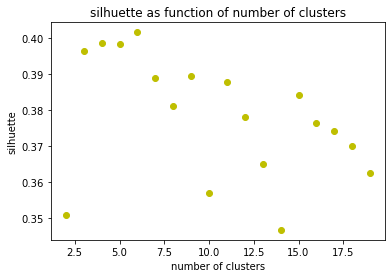

In [147]:
# Plot the silhuette
plt.scatter(xSilh, silh,label='Centers',color='y')
plt.xlabel('number of clusters')
plt.ylabel('silhuette')
plt.title('silhuette as function of number of clusters')
#plt.legend()
plt.show()

In [149]:
silh

[0.3510058343032424,
 0.3963046104134062,
 0.3984988561102429,
 0.3983553411905185,
 0.4015221995023217,
 0.38871622486733687,
 0.38098963505602296,
 0.38930765380359833,
 0.35693187661046166,
 0.3877600180536093,
 0.37807802440723626,
 0.365067149624796,
 0.34678112295071345,
 0.38421492724499995,
 0.37630562474915735,
 0.37413662054286706,
 0.36998941033198474,
 0.36258738532616114]

In [150]:
xSilh

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

In [199]:
best_model = models[5]

predictions = best_model.transform(dataset).toPandas()

## 5.  Use PCA to reduce the dimensions of feature vector. 
Is it more helpful for clustering? Fill following table for applying PCA with
5, 4, and 3 features.

| Clusters ID | The number of players from the 10 players with biggest salary<br> |
| ----------- | ----------------------------------------------------------------- |
|             |                                                                   |


In [176]:
from pyspark.ml.functions import vector_to_array
from pyspark.ml.feature import PCA
from pyspark.ml.linalg import Vectors

pca = PCA(k=2, inputCol="features", outputCol="pcaFeatures")
model = pca.fit(dataset)

result = model.transform(dataset).select("pcaFeatures")
result.show()

+--------------------+
|         pcaFeatures|
+--------------------+
|[-18.983098261741...|
|[-16.679781817990...|
|[-19.651230742117...|
|[-12.596935918637...|
|[-19.001945080761...|
|[-17.505622711048...|
|[-16.655506007834...|
|[-16.953018293209...|
|[-14.738125949008...|
|[-12.164803647348...|
|[-15.630972648240...|
|[-16.410999989220...|
|[-12.985790541811...|
|[-14.792964744959...|
|[-16.133311181147...|
|[-16.687352831909...|
|[-16.630638366385...|
|[-16.585031189201...|
|[-11.022631298735...|
|[-10.869572876384...|
+--------------------+
only showing top 20 rows



In [181]:
result.collect()[8300:8330]

[Row(pcaFeatures=DenseVector([-6.4878, 2.8028])),
 Row(pcaFeatures=DenseVector([-8.477, 1.9651])),
 Row(pcaFeatures=DenseVector([-8.659, 0.7816])),
 Row(pcaFeatures=DenseVector([-7.1008, 2.437])),
 Row(pcaFeatures=DenseVector([-8.1785, 1.9538])),
 Row(pcaFeatures=DenseVector([-7.7301, 2.5297])),
 Row(pcaFeatures=DenseVector([-8.1296, 2.417])),
 Row(pcaFeatures=DenseVector([-8.2876, 1.6877])),
 Row(pcaFeatures=DenseVector([-8.5258, 1.0942])),
 Row(pcaFeatures=DenseVector([-8.6116, 1.4013])),
 Row(pcaFeatures=DenseVector([-8.4631, 1.3728])),
 Row(pcaFeatures=DenseVector([-9.1728, 0.8783])),
 Row(pcaFeatures=DenseVector([-8.4548, 0.9004])),
 Row(pcaFeatures=DenseVector([-7.4516, 3.0182])),
 Row(pcaFeatures=DenseVector([-9.1106, 1.678])),
 Row(pcaFeatures=DenseVector([-8.522, 1.8162])),
 Row(pcaFeatures=DenseVector([-8.336, 0.6076])),
 Row(pcaFeatures=DenseVector([-7.7262, 2.8964])),
 Row(pcaFeatures=DenseVector([-6.6516, 3.3308])),
 Row(pcaFeatures=DenseVector([-7.8632, 0.5833])),
 Row(pc

In [189]:

pdf = result \
.withColumn("pcaFeatures", vector_to_array("pcaFeatures")) \
.select(col("pcaFeatures").getItem(0).alias("PCA1"),
        col("pcaFeatures").getItem(1).alias("PCA2")
).toPandas()





#withColumn("xs", vector_to_array("pcaFeatures")).show()#.select(["p1","p2"])

In [190]:
pdf

,PCA1,PCA2
0,-18.983098,11.553590
1,-16.679782,8.938042
2,-19.651231,11.351471
3,-12.596936,7.961255
4,-19.001945,9.533334
...,...,...
18202,-5.806733,0.976521
18203,-5.073774,1.394610
18204,-5.498426,1.678652
18205,-5.417427,1.664221


In [206]:
from sklearn.manifold import TSNE
def embedding_Tsne(df_subset, lbl):
    tsne = TSNE(n_components=2, verbose=1, perplexity=5, n_iter=300)
    tsne_results = tsne.fit_transform(df_subset)
    df_subset['tsne-2d-one'] = tsne_results[:,0]
    df_subset['tsne-2d-two'] = tsne_results[:,1]
    df_subset['word'] = df_subset.index
    df_subset['embedding'] = lbl
    return df_subset

In [222]:
TSNEd = embedding_Tsne(predictions[['Age', 'Value', 'LM', 'Stamina', 'SlidingTackle']],'bla')


/home/linuxu/anaconda3/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning:

The default initialization in TSNE will change from 'random' to 'pca' in 1.2.

/home/linuxu/anaconda3/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning:

The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.



[t-SNE] Computing 16 nearest neighbors...
[t-SNE] Indexed 18207 samples in 0.011s...
[t-SNE] Computed neighbors for 18207 samples in 0.121s...
[t-SNE] Computed conditional probabilities for sample 1000 / 18207
[t-SNE] Computed conditional probabilities for sample 2000 / 18207
[t-SNE] Computed conditional probabilities for sample 3000 / 18207
[t-SNE] Computed conditional probabilities for sample 4000 / 18207
[t-SNE] Computed conditional probabilities for sample 5000 / 18207
[t-SNE] Computed conditional probabilities for sample 6000 / 18207
[t-SNE] Computed conditional probabilities for sample 7000 / 18207
[t-SNE] Computed conditional probabilities for sample 8000 / 18207
[t-SNE] Computed conditional probabilities for sample 9000 / 18207
[t-SNE] Computed conditional probabilities for sample 10000 / 18207
[t-SNE] Computed conditional probabilities for sample 11000 / 18207
[t-SNE] Computed conditional probabilities for sample 12000 / 18207
[t-SNE] Computed conditional probabilities for sam

/tmp/ipykernel_323372/4253547871.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_323372/4253547871.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [223]:
TSNEd

,Age,Value,LM,Stamina,SlidingTackle,tsne-2d-one,tsne-2d-two,word,embedding
0,31,110500000,91,72,26,-7.471308,-9.902727,0,bla
1,33,77000000,88,88,23,-7.460283,-9.902773,1,bla
2,26,118500000,88,81,33,-7.471205,-9.902726,2,bla
3,27,72000000,60,43,13,-7.431333,-9.902353,3,bla
4,27,102000000,88,90,51,-7.471130,-9.902747,4,bla
...,...,...,...,...,...,...,...,...,...
18202,19,60000,44,40,47,-1.250356,-2.261468,18202,bla
18203,19,60000,38,43,19,-0.834362,-3.207444,18203,bla
18204,16,60000,44,55,11,-0.839896,-3.232698,18204,bla
18205,17,60000,46,40,27,-0.863307,-3.172407,18205,bla


In [212]:
import seaborn as sns

In [229]:
rich = TSNEd.sort_values("Value", ascending=False)[:10]

,Age,Value,LM,Stamina,SlidingTackle,tsne-2d-one,tsne-2d-two,word,embedding
2,26,118500000,88,81,33,-7.471205,-9.902726,2,bla
0,31,110500000,91,72,26,-7.471308,-9.902727,0,bla
4,27,102000000,88,90,51,-7.471130,-9.902747,4,bla
5,27,93000000,89,83,22,-7.470000,-9.902746,5,bla
15,24,89000000,86,80,20,-7.469337,-9.902740,15,bla
16,24,83500000,81,89,38,-7.467176,-9.902766,16,bla
25,19,81000000,86,83,32,-7.465847,-9.902767,25,bla
7,31,80000000,84,90,38,-7.465065,-9.902786,7,bla
17,27,78000000,86,83,48,-7.462224,-9.902778,17,bla
10,29,77000000,81,78,19,-7.460279,-9.902775,10,bla


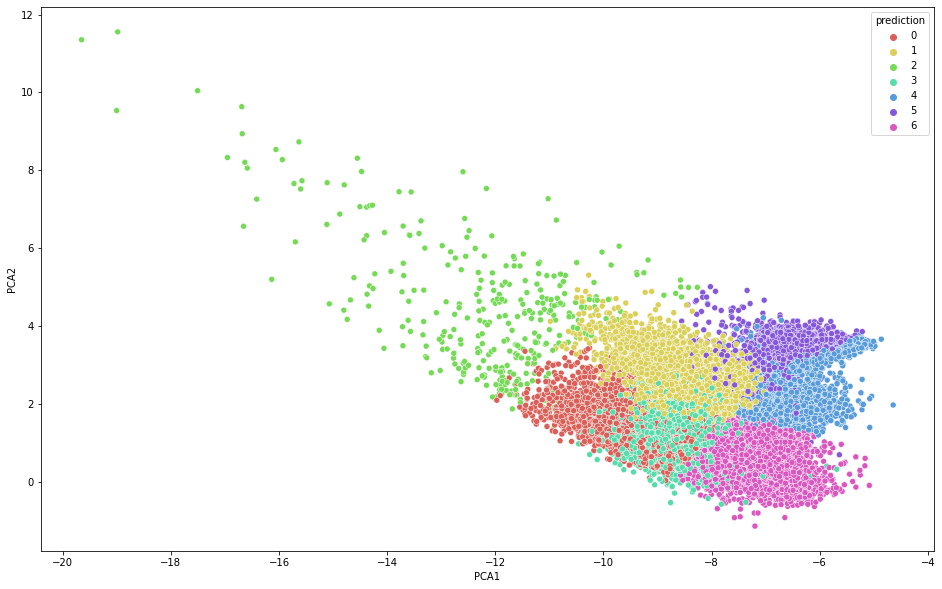

In [227]:
plt.figure(figsize=(16,10))
ax = sns.scatterplot(
    #x="tsne-2d-one", y="tsne-2d-two",
    x = pdf.PCA1, y = pdf.PCA2,
    hue=predictions["prediction"],
    palette=sns.color_palette("hls", 7),
    data=TSNEd,
)
ax.scatter(data=rich, )


In [ ]:

def compare_embeddings(embeddings: list):
    toplot = pd.concat(embeddings)

    plt.figure(figsize=(16,10))

    # draw black line connecting different enbeddings of same word 
    wds = toplot.word.unique()
    for w in wds:
        ln = toplot[toplot.word == w] 
        plt.plot(ln["tsne-2d-one"], ln["tsne-2d-two"], '-', color='k')

    # draw all the points (words)
    ax = sns.scatterplot(
        x="tsne-2d-one", y="tsne-2d-two",
        hue="embedding",
        palette=sns.color_palette("hls", ln.shape[0]),
        data=toplot,
        #legend="full",
        #alpha=0.3
    )

    # draw word labels near each point 
    for i, point in toplot.iterrows():
        ax.text(point["tsne-2d-one"]+.02, point["tsne-2d-two"], str(point['word']))#, color = point["embedding"] )

In [200]:
predictions

,Age,Value,LM,Stamina,SlidingTackle,vectors,features,prediction
0,31,110500000,91,72,26,"[31.0, 110500000.0, 91.0, 72.0, 26.0]","[6.638197062022439, 19.750014258044573, 10.474...",2
1,33,77000000,88,88,23,"[33.0, 77000000.0, 88.0, 88.0, 23.0]","[7.066467840217435, 13.762453374384002, 10.129...",2
2,26,118500000,88,81,33,"[26.0, 118500000.0, 88.0, 81.0, 33.0]","[5.567520116534949, 21.17987954369486, 10.1296...",2
3,27,72000000,60,43,13,"[27.0, 72000000.0, 60.0, 43.0, 13.0]","[5.781655505632447, 12.868787570852573, 6.9065...",2
4,27,102000000,88,90,51,"[27.0, 102000000.0, 88.0, 90.0, 51.0]","[5.781655505632447, 18.230782392041146, 10.129...",2
...,...,...,...,...,...,...,...,...
18202,19,60000,44,40,47,"[19.0, 60000.0, 44.0, 40.0, 47.0]","[4.068572392852462, 0.010723989642377144, 5.06...",6
18203,19,60000,38,43,19,"[19.0, 60000.0, 38.0, 43.0, 19.0]","[4.068572392852462, 0.010723989642377144, 4.37...",4
18204,16,60000,44,55,11,"[16.0, 60000.0, 44.0, 55.0, 11.0]","[3.4261662255599683, 0.010723989642377144, 5.0...",4
18205,17,60000,46,40,27,"[17.0, 60000.0, 46.0, 40.0, 27.0]","[3.6403016146574663, 0.010723989642377144, 5.2...",4


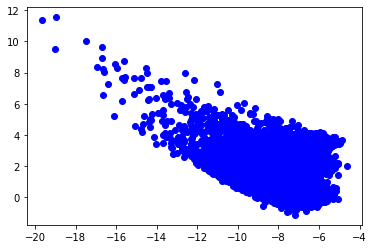

In [225]:
plt.scatter(pdf.PCA1, pdf.PCA2,label=predictions["prediction"],color='b')

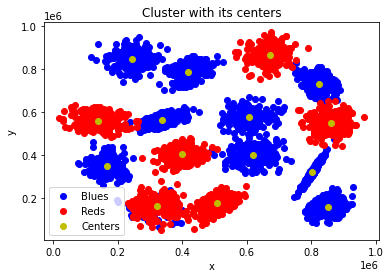

In [24]:
x = []
y = []

file = open('5000_points.txt', 'r')
for line in file.readlines():
    words = line.split()
    x.append(int(words[0]))
    y.append(int(words[1]))
file.close()

x1 = x[:3000]
y1 = y[:3000]

x2 = x[3000:]
y2 = y[3000:]
plt.scatter(x1, y1,label='Blues',color='b')
plt.scatter(x2, y2,label='Reds',color='r')

numOfClusters = 15
kmeans = KMeans().setK(numOfClusters).setSeed(1)
model = kmeans.fit(dataset)

xCenter = []
yCenter = []
centers = model.clusterCenters()
for center in centers:
    xCenter.append(center[0])
    yCenter.append(center[1])

plt.scatter(xCenter, yCenter, label='Centers',color='y')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Cluster with its centers')
plt.legend()
plt.show()

## 6.  Perform task 6 with reduction to two features only. 
Draw 2D plot of clusters and top 10 players with biggest salary.
